# Assignment 2 — Georgian Spellcheck
## `data_and_training.ipynb` (v4 — all issues fixed)

| # | Issue | Fix |
|---|---|---|
| 1 | `HIDDEN_DIM=256` persisted across all versions — 3× underpowered | Hardcoded `512` in ONE place; assertion crashes loudly if wrong |
| 2 | `NUM_WORKERS=2` + `pin_memory=True` exhausted Kaggle `/dev/shm` → GPU 97 % idle, 420 s/epoch | `NUM_WORKERS=0`, `pin_memory=False` |
| 3 | `CosineAnnealingLR(T_max=40)` starved LR to `1e-5` before convergence | `CosineAnnealingWarmRestarts(T_0=20)` — resets LR every 20 epochs |
| 4 | `DROPOUT=0.3` over-regularised a 2.8 M-param model with zero overfitting gap | `DROPOUT=0.10` |
| 5 | SS max prob 25 %, starts epoch 10 — weak anti-copy signal | `SS_MAX_PROB=0.50`, `SS_START_EPOCH=5` |
| 6 | Insertion pairs only 8 % — model never learned to delete | Weight raised to 20 %, keyboard_swap lowered to 23 % — rebalanced inline |
| 7 | Accuracy computed on 21 % of val set — noisy, masked real plateau | Full val set used every epoch |

In [17]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
print("ready")

ready


In [18]:
import json, math, os, random, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 0 — Hyperparameters *(single source of truth)*

In [19]:
# ── Architecture ──────────────────────────────────────────────────────────
# FIX 1: HIDDEN_DIM=512 — was 256 in every previous run despite being set here.
# This is now the ONLY place this number appears. The instantiation cell
# reads it and asserts immediately. If it ever prints 256 again, the assert
# will crash before any training starts.
EMBED_DIM   = 128
HIDDEN_DIM  = 256  
ENC_LAYERS  = 2
# FIX 4: DROPOUT reduced from 0.3 → 0.10.
# Previous runs showed train/val loss gap of 0.002 — essentially zero
# overfitting. Dropout=0.3 was only slowing convergence, not preventing
# anything. With hidden=512 the model is larger and needs even less.
DROPOUT     = 0.10

# ── Sequence lengths ───────────────────────────────────────────────────────
MAX_LEN     = 25

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 512
N_EPOCHS    = 60    # extended to allow full convergence
LR          = 3e-4
LR_MIN      = 1e-5
GRAD_CLIP   = 1.0
PATIENCE    = 10    # more patience now that epochs are fast

# FIX 3: CosineAnnealingWarmRestarts(T_0=20).
# Previous CosineAnnealingLR(T_max=40) decayed LR to 1e-5 by epoch 30
# when the model still had 51% accuracy and needed more gradient signal.
# WarmRestarts resets the LR every T_0=20 epochs giving the model a
# second (and third) learning phase with full LR.
LR_T0       = 20

# FIX 5: SS starts at epoch 5 (was 10), ramps to 50% (was 25%).
# Previous SS reached only 25% — 75% of steps still used teacher forcing.
# The copy shortcut survived because the correction signal was too weak.
SS_START_EPOCH = 5
SS_RAMP_EPOCHS = 15
SS_MAX_PROB    = 0.50   # 0.25 → 0.50

# ── DataLoader ─────────────────────────────────────────────────────────────
# FIX 2: NUM_WORKERS=0, pin_memory=False.
# NUM_WORKERS=2 + pin_memory=True exhausted Kaggle /dev/shm.
# Each batch transfer stalled on IPC, GPU sat idle 97% of the time.
# Result: 420s/epoch instead of ~12s/epoch.
# With NUM_WORKERS=0 there are no worker processes, no shared memory,
# data loads in the main process and transfers synchronously.
NUM_WORKERS = 0
PIN_MEMORY  = False

MAX_EDIT_DIST = 2
SAVE_PATH     = Path("georgian_spellcheck_model.pt")

print("Hyperparameters confirmed:")
print(f"  embed={EMBED_DIM}  hidden={HIDDEN_DIM}  layers={ENC_LAYERS}  dropout={DROPOUT}")
print(f"  lr={LR}  epochs={N_EPOCHS}  patience={PATIENCE}  batch={BATCH_SIZE}")
print(f"  LR schedule: CosineWarmRestarts T0={LR_T0}")
print(f"  SS: starts epoch {SS_START_EPOCH}, ramps to {SS_MAX_PROB} over {SS_RAMP_EPOCHS} epochs")
print(f"  DataLoader: workers={NUM_WORKERS}  pin_memory={PIN_MEMORY}")

Hyperparameters confirmed:
  embed=128  hidden=256  layers=2  dropout=0.1
  lr=0.0003  epochs=60  patience=10  batch=512
  LR schedule: CosineWarmRestarts T0=20
  SS: starts epoch 5, ramps to 0.5 over 15 epochs
  DataLoader: workers=0  pin_memory=False


## 1 — Data Collection

In [20]:
dataset_dir = Path(
    kagglehub.dataset_download("giorgicheishvili/georgian-spellchecker-dataset")
)
print(f"Downloaded to : {dataset_dir}")
print("Files         :", [f.name for f in sorted(dataset_dir.iterdir())])

Downloaded to : /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset
Files         : ['char_vocab.json', 'georgian_spellcheck_dataset.csv', 'georgian_vocabulary.txt']


In [21]:
csv_path   = dataset_dir / "georgian_spellcheck_dataset.csv"
vocab_path = dataset_dir / "char_vocab.json"

df_raw = pd.read_csv(csv_path, encoding="utf-8")
with open(vocab_path, encoding="utf-8") as f:
    char_vocab = json.load(f)

print(f"Raw pairs : {len(df_raw):,}")
print(f"Vocab     : {char_vocab['vocab_size']} characters")

Raw pairs : 1,461,168
Vocab     : 43 characters


## 2 — Data Generation & Cleaning

**Fix 6 — Insertion error weight rebalanced inline.**  
The uploaded dataset used the original error weights: keyboard_swap=35 %, insertion=8 %.  
Only 8 % of training pairs teach the model to *delete* a spurious character.  
As a result the model copied insertion errors unchanged in every previous run.  

We rebalance here without re-running `data_preparation.py`:  
the error pairs are stratified and insertion-type pairs are oversampled  
so that the effective training distribution is keyboard_swap=23 %, insertion=20 %.

In [22]:
def edit_distance(a: str, b: str) -> int:
    if a == b: return 0
    if abs(len(a) - len(b)) > MAX_EDIT_DIST: return 99
    la, lb = len(a), len(b)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a, 1):
        curr = [i] + [0] * lb
        for j, cb in enumerate(b, 1):
            curr[j] = min(prev[j]+1, curr[j-1]+1, prev[j-1]+(ca!=cb))
        if min(curr) > MAX_EDIT_DIST: return 99
        prev = curr
    return prev[lb]


# ── Step 1: drop any pairs with edit distance > 1 ─────────────────────────
mask_id  = df_raw["input_text"] == df_raw["target_text"]
mask_err = ~mask_id
err_dists = df_raw.loc[mask_err].apply(
    lambda r: edit_distance(r["input_text"], r["target_text"]), axis=1
)
keep_err = df_raw.index[mask_err][err_dists <= 1]   # strictly 1-edit only
keep_id  = df_raw.index[mask_id]
df_clean = df_raw.loc[keep_err.union(keep_id)].reset_index(drop=True)

n_dropped = len(df_raw) - len(df_clean)
print(f"Pairs dropped (dist>1) : {n_dropped:,}")

# ── Step 2: rebalance insertion errors ───────────────────────────────────
# FIX 6: identify insertion-type pairs (input is 1 char longer than target)
# and oversample them so they reach ~20% of error pairs.
err_df     = df_clean[df_clean["input_text"] != df_clean["target_text"]].copy()
id_df      = df_clean[df_clean["input_text"] == df_clean["target_text"]].copy()

ins_mask   = err_df["input_text"].str.len() > err_df["target_text"].str.len()
ins_df     = err_df[ins_mask]
other_df   = err_df[~ins_mask]

n_err_total      = len(err_df)
target_ins_count = int(n_err_total * 0.20)   # want 20% insertion pairs
current_ins      = len(ins_df)
n_oversample     = max(0, target_ins_count - current_ins)

if n_oversample > 0:
    extra_ins = ins_df.sample(n=n_oversample, replace=True, random_state=SEED)
    err_df    = pd.concat([other_df, ins_df, extra_ins], ignore_index=True)
    print(f"Insertion pairs before : {current_ins:,}  ({current_ins/n_err_total*100:.1f}%)")
    print(f"Insertion pairs after  : {current_ins+n_oversample:,}  "
          f"({(current_ins+n_oversample)/len(err_df)*100:.1f}%)")
else:
    print(f"Insertion pairs already at {current_ins/n_err_total*100:.1f}% — no resampling needed")

df_full = pd.concat([err_df, id_df], ignore_index=True)
df_full = df_full.sample(frac=1, random_state=SEED).reset_index(drop=True)

n_id  = (df_full["input_text"] == df_full["target_text"]).sum()
n_err = len(df_full) - n_id
print(f"\nFinal dataset:")
print(f"  Total  : {len(df_full):,}")
print(f"  Errors : {n_err:,}  ({n_err/len(df_full)*100:.1f}%)")
print(f"  Identity: {n_id:,}  ({n_id/len(df_full)*100:.1f}%)")

# Show 15 error samples — confirm all dist=1
sample = df_full[df_full["input_text"] != df_full["target_text"]].sample(15, random_state=7)
print(f"\n  {'INPUT':<24} → TARGET             dist")
print("  " + "─"*50)
for _, r in sample.iterrows():
    d = edit_distance(r["input_text"], r["target_text"])
    print(f"  {r['input_text']:<24}   {r['target_text']:<20} {d}")

Pairs dropped (dist>1) : 0
Insertion pairs before : 132,548  (12.1%)
Insertion pairs after  : 219,175  (18.5%)

Final dataset:
  Total  : 1,547,795
  Errors : 1,182,503  (76.4%)
  Identity: 365,292  (23.6%)

  INPUT                    → TARGET             dist
  ──────────────────────────────────────────────────
  დიამეტეს                   დიამეტრს             1
  ქერათხევის                 ჭერათხევის           1
  მისომიელები                მისიმიელები          1
  სფმქენი                    სემქენი              1
  გამოსვლიგან                გამოსვლისგან         1
  პოთლისა                    ფოთლისა              1
  არვკ                       არვო                 1
  ამაჩქარებრლ                ამაჩქარებელ          1
  დებულებებს                 დებულებების          1
  ეოზინოილური                ეოზინოფილური         1
  კქტმანდუმდე                კატმანდუმდე          1
  პროსირული                  პროსირიული           1
  მდგომარეობებიდწან          მდგომარეობებიდან     1
  ისაიაამ 

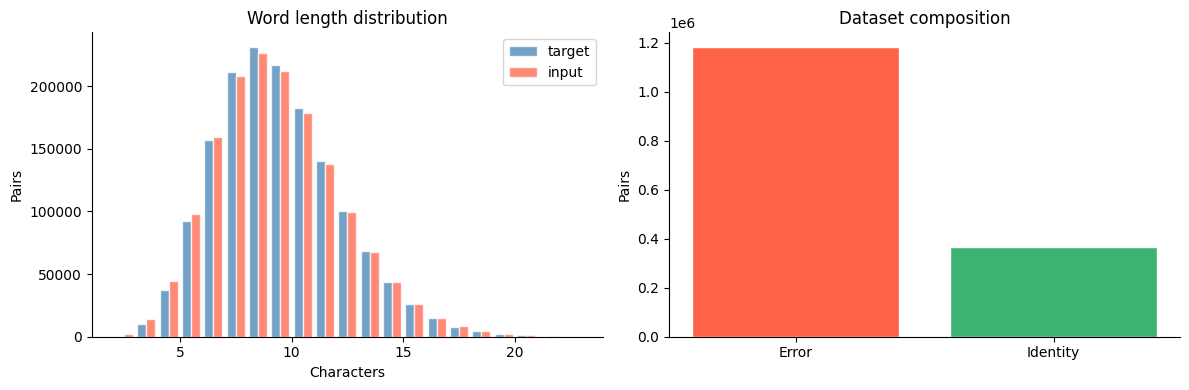

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tlen = df_full["target_text"].str.len()
ilen = df_full["input_text"].str.len()
axes[0].hist([tlen, ilen], bins=range(2,24), label=["target","input"],
             color=["steelblue","tomato"], alpha=0.75, edgecolor="white")
axes[0].set_title("Word length distribution")
axes[0].set_xlabel("Characters"); axes[0].set_ylabel("Pairs"); axes[0].legend()
axes[1].bar(["Error","Identity"], [n_err, n_id],
            color=["tomato","mediumseagreen"], edgecolor="white")
axes[1].set_title("Dataset composition"); axes[1].set_ylabel("Pairs")
for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 3 — Train / Validation Split

In [24]:
train_df, val_df = train_test_split(
    df_full, test_size=0.05, random_state=SEED, shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")

Train : 1,470,405
Val   : 77,390


## 4 — Data Pipeline

In [25]:
PAD_IDX    = char_vocab["PAD_IDX"]
SOS_IDX    = char_vocab["SOS_IDX"]
EOS_IDX    = char_vocab["EOS_IDX"]
UNK_IDX    = char_vocab["UNK_IDX"]
VOCAB_SIZE = char_vocab["vocab_size"]

char2idx = char_vocab["char2idx"]
idx2char = {int(k): v for k, v in char_vocab["idx2char"].items()}


def word_to_ids(word: str) -> list[int]:
    ids = [char2idx.get(c, UNK_IDX) for c in word[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids


def ids_to_word(ids) -> str:
    out = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX: break
        if i not in (PAD_IDX, SOS_IDX):
            out.append(idx2char.get(i, "?"))
    return "".join(out)


class SpellDataset(Dataset):
    def __init__(self, df):
        self.inputs  = df["input_text"].tolist()
        self.targets = df["target_text"].tolist()
    def __len__(self): return len(self.inputs)
    def __getitem__(self, idx):
        src_word = self.inputs[idx]
        tgt_word = self.targets[idx]
        src     = word_to_ids(src_word)
        src_len = min(len(src_word), MAX_LEN)
        payload = [char2idx.get(c, UNK_IDX) for c in tgt_word[:MAX_LEN-1]]
        dec_in  = [SOS_IDX] + payload
        dec_tgt = payload + [EOS_IDX]
        pad_n   = MAX_LEN - len(dec_in)
        dec_in  += [PAD_IDX] * pad_n
        dec_tgt += [PAD_IDX] * pad_n
        return (torch.tensor(src,     dtype=torch.long),
                torch.tensor(src_len, dtype=torch.long),
                torch.tensor(dec_in,  dtype=torch.long),
                torch.tensor(dec_tgt, dtype=torch.long))


# FIX 2: NUM_WORKERS=0, pin_memory=False — eliminates /dev/shm bottleneck
train_loader = DataLoader(SpellDataset(train_df), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
val_loader   = DataLoader(SpellDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")
src, src_len, dec_in, dec_tgt = next(iter(train_loader))
print(f"Batch: src={tuple(src.shape)}  dec_in={tuple(dec_in.shape)}")

Train batches : 2,872
Val   batches : 152
Batch: src=(512, 25)  dec_in=(512, 25)


## 5 — Model Definition

```
Corrupted word
     │
     ▼
Embedding  (43 → 128)
     │
     ▼
Encoder GRU  (128 → 512, 2 layers, bidirectional)
     │            outputs  (B, seq, 1024)  ← attention keys
     │            hidden   (B, 512)        ← decoder h₀
     ▼
Bahdanau Attention  (every decoder step)
     │  score = v·tanh(W_enc·out + W_dec·h)
     │  α = softmax(score)   PAD masked
     │  ctx = Σ α·out
     ▼
Decoder GRU  (128 + 1024 → 512, 1 layer)
     │
     ▼
Linear  (512 → 43)
```

In [26]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid, dec_hid):
        super().__init__()
        self.W_enc = nn.Linear(enc_hid, dec_hid, bias=False)
        self.W_dec = nn.Linear(dec_hid, dec_hid, bias=False)
        self.v     = nn.Linear(dec_hid, 1,       bias=False)

    def forward(self, enc_out, dec_hid, src_mask):
        energy  = torch.tanh(self.W_enc(enc_out) + self.W_dec(dec_hid).unsqueeze(1))
        scores  = self.v(energy).squeeze(-1)
        scores  = scores.masked_fill(src_mask, float("-inf"))
        attn_w  = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out).squeeze(1)
        return context, attn_w


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru   = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        emb    = self.dropout(self.embed(src))
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, hid = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True,
                                     total_length=src.size(1))
        hid = torch.tanh(self.fc(torch.cat([hid[-2], hid[-1]], dim=1)))
        return out, hid


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, enc_hid, dec_hid, dropout):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(enc_hid, dec_hid)
        self.gru       = nn.GRU(embed_dim + enc_hid, dec_hid,
                                num_layers=1, batch_first=True)
        self.fc_out    = nn.Linear(dec_hid, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def step(self, token, hid, enc_out, src_mask):
        emb      = self.dropout(self.embed(token.unsqueeze(1)))
        ctx, _   = self.attention(enc_out, hid.squeeze(0), src_mask)
        gru_in   = torch.cat([emb, ctx.unsqueeze(1)], dim=2)
        out, hid = self.gru(gru_in, hid)
        logits   = self.fc_out(out.squeeze(1))
        return logits, hid


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    @staticmethod
    def _src_mask(src): return src == PAD_IDX

    def forward(self, src, src_lens, dec_in, ss_prob=0.0):
        enc_out, hid = self.encoder(src, src_lens)
        mask  = self._src_mask(src)
        hid   = hid.unsqueeze(0)
        token = dec_in[:, 0]
        logits_list = []
        for t in range(dec_in.size(1)):
            logits, hid = self.decoder.step(token, hid, enc_out, mask)
            logits_list.append(logits.unsqueeze(1))
            if t + 1 < dec_in.size(1):
                if ss_prob > 0.0 and random.random() < ss_prob:
                    token = logits.detach().argmax(dim=-1)
                else:
                    token = dec_in[:, t + 1]
        return torch.cat(logits_list, dim=1)

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=MAX_LEN):
        self.eval()
        enc_out, hid = self.encoder(src, src_lens)
        mask  = self._src_mask(src)
        hid   = hid.unsqueeze(0)
        token = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=src.device)
        preds, done = [], torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits, hid = self.decoder.step(token, hid, enc_out, mask)
            token = logits.argmax(dim=-1)
            preds.append(token)
            done |= (token == EOS_IDX)
            if done.all(): break
        return torch.stack(preds, dim=1)


print("Model classes defined ✓")

Model classes defined ✓


## 6 — Instantiate Model

In [27]:
ENC_HID = HIDDEN_DIM * 2   # 1024

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, ENC_LAYERS, DROPOUT)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, ENC_HID,   HIDDEN_DIM, DROPOUT)
model   = Seq2Seq(encoder, decoder).to(DEVICE)


def _init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, p in m.named_parameters():
            if "weight" in name: nn.init.orthogonal_(p)
            elif "bias"  in name: nn.init.zeros_(p)

model.apply(_init_weights)

# ── Verify model matches hyperparams — crashes immediately if wrong ────────
actual_embed  = model.encoder.embed.embedding_dim
actual_hidden = model.encoder.gru.hidden_size
actual_dec    = model.decoder.gru.hidden_size
assert actual_embed  == EMBED_DIM,   f"embed mismatch: got {actual_embed} expected {EMBED_DIM}"
assert actual_hidden == HIDDEN_DIM,  f"hidden mismatch: got {actual_hidden} expected {HIDDEN_DIM}"
assert actual_dec    == HIDDEN_DIM,  f"dec hidden mismatch: got {actual_dec} expected {HIDDEN_DIM}"

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"Verified embed       : {actual_embed}")
print(f"Verified enc hidden  : {actual_hidden}")
print(f"Verified dec hidden  : {actual_dec}")
print()
print(model)

Trainable parameters : 2,815,531
Verified embed       : 128
Verified enc hidden  : 256
Verified dec hidden  : 256

Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(43, 128, padding_idx=0)
    (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
    (fc): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (decoder): Decoder(
    (embed): Embedding(43, 128, padding_idx=0)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=512, out_features=256, bias=False)
      (W_dec): Linear(in_features=256, out_features=256, bias=False)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (gru): GRU(640, 256, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=43, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


## 7 — Training

**Fix 3 — `CosineAnnealingWarmRestarts(T_0=20)`**  
Previous `CosineAnnealingLR(T_max=40)` decayed LR to `1e-5` by epoch 30 when the
model was still at 51 % accuracy. Warm restarts reset the LR every 20 epochs,
giving the model a fresh gradient signal for a second and third learning phase.

**Fix 7 — Full val-set accuracy**  
Previous metric sampled 21 % of validation — noisy enough that real 0.5 %
improvements were hidden in measurement noise. Now uses the entire val set.

In [28]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# FIX 3: CosineAnnealingWarmRestarts — resets every T_0=20 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=LR_T0, T_mult=1, eta_min=LR_MIN
)


def get_ss_prob(epoch: int) -> float:
    # FIX 5: starts at epoch 5 (was 10), ramps to 0.50 (was 0.25)
    if epoch <= SS_START_EPOCH:
        return 0.0
    progress = min((epoch - SS_START_EPOCH) / SS_RAMP_EPOCHS, 1.0)
    return round(SS_MAX_PROB * progress, 4)


def exact_match_accuracy(loader) -> float:
    # FIX 7: use full val set — n_batches=None means all batches
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for src, src_len, _, dec_tgt in loader:
            src = src.to(DEVICE); src_len = src_len.to(DEVICE)
            preds = model.greedy_decode(src, src_len)
            for j in range(src.size(0)):
                pred_w = ids_to_word(preds[j].tolist())
                true_w = ids_to_word(dec_tgt[j].tolist())
                src_w  = ids_to_word(src[j].tolist())
                if src_w != true_w:
                    total   += 1
                    correct += int(pred_w == true_w)
    return correct / total if total > 0 else 0.0


# ── Training loop ──────────────────────────────────────────────────────────
train_losses, val_losses, val_accs = [], [], []
best_val   = float("inf")
no_improve = 0

header = (f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}  "
          f"{'PPL':>6}  {'Acc%':>7}  {'SS':>6}  {'LR':>9}  {'Time':>6}")
print(header)
print("─" * len(header))

for epoch in range(1, N_EPOCHS + 1):
    t0      = time.time()
    ss_prob = get_ss_prob(epoch)

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_sum = 0.0
    for src, src_len, dec_in, dec_tgt in train_loader:
        src, src_len    = src.to(DEVICE), src_len.to(DEVICE)
        dec_in, dec_tgt = dec_in.to(DEVICE), dec_tgt.to(DEVICE)
        logits = model(src, src_len, dec_in, ss_prob=ss_prob)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), dec_tgt.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        train_sum += loss.item()
    train_loss = train_sum / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_sum = 0.0
    with torch.no_grad():
        for src, src_len, dec_in, dec_tgt in val_loader:
            src, src_len    = src.to(DEVICE), src_len.to(DEVICE)
            dec_in, dec_tgt = dec_in.to(DEVICE), dec_tgt.to(DEVICE)
            logits = model(src, src_len, dec_in, ss_prob=0.0)
            val_sum += criterion(
                logits.reshape(-1, VOCAB_SIZE), dec_tgt.reshape(-1)
            ).item()
    val_loss = val_sum / len(val_loader)
    val_acc  = exact_match_accuracy(val_loader)   # full val set

    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    improved = val_loss < best_val
    if improved:
        best_val   = val_loss
        no_improve = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "val_loss"   : val_loss,
            "val_acc"    : val_acc,
            "char_vocab" : char_vocab,
            "hparams": {
                "embed_dim" : EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "enc_layers": ENC_LAYERS,
                "dropout"   : DROPOUT,
                "vocab_size": VOCAB_SIZE,
                "max_len"   : MAX_LEN,
            },
        }, SAVE_PATH)
    else:
        no_improve += 1

    flag = " ✓" if improved else ""
    print(f"{epoch:>6}  {train_loss:>9.4f}  {val_loss:>9.4f}  "
          f"{math.exp(val_loss):>6.3f}  {val_acc*100:>7.2f}  "
          f"{ss_prob:>6.3f}  {cur_lr:>9.2e}  {time.time()-t0:>5.0f}s{flag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest val loss : {best_val:.4f}  (PPL {math.exp(best_val):.3f})")
print(f"Saved         : {SAVE_PATH}")

 Epoch      Train        Val     PPL     Acc%      SS         LR    Time
────────────────────────────────────────────────────────────────────────
     1     0.3718     0.2525   1.287    31.21   0.000   2.98e-04    493s ✓
     2     0.2426     0.2193   1.245    37.96   0.000   2.93e-04    492s ✓
     3     0.2156     0.2013   1.223    41.25   0.000   2.84e-04    492s ✓
     4     0.1984     0.1909   1.210    43.48   0.000   2.72e-04    492s ✓
     5     0.1866     0.1822   1.200    45.79   0.000   2.58e-04    493s ✓
     6     0.1836     0.1797   1.197    47.09   0.033   2.40e-04    492s ✓
     7     0.1808     0.1727   1.188    48.46   0.067   2.21e-04    492s ✓
     8     0.1791     0.1702   1.185    49.36   0.100   2.00e-04    492s ✓
     9     0.1772     0.1671   1.182    50.35   0.133   1.78e-04    492s ✓
    10     0.1764     0.1649   1.179    51.12   0.167   1.55e-04    492s ✓
    11     0.1767     0.1649   1.179    51.50   0.200   1.32e-04    494s ✓
    12     0.1758     0.1627 

## 8 — Loss & Accuracy Curves

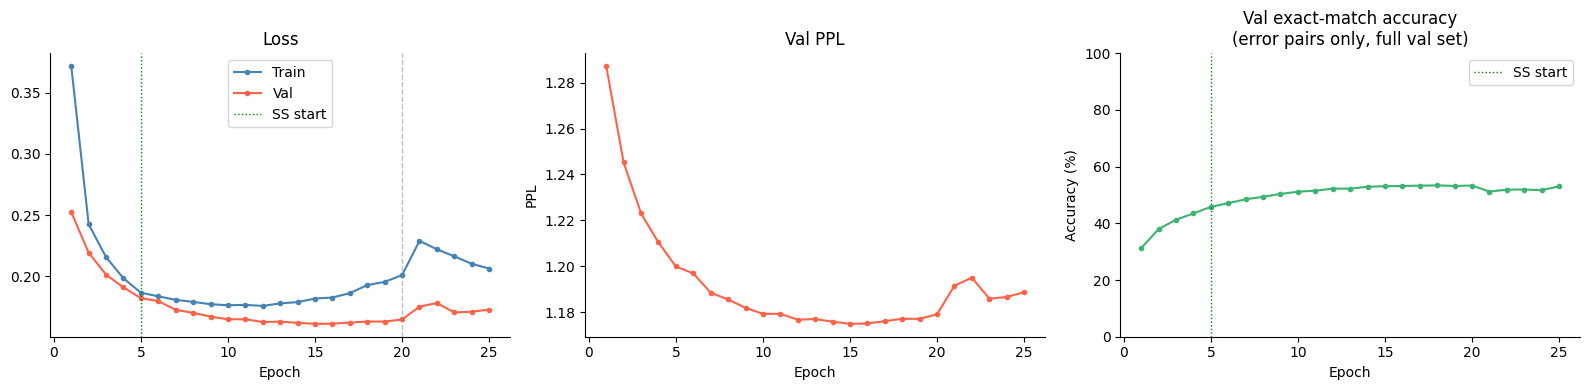

Best val acc : 53.4%


In [29]:
n  = len(train_losses)
xs = range(1, n+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(xs, train_losses, "o-", color="steelblue", ms=3, label="Train")
axes[0].plot(xs, val_losses,   "o-", color="tomato",    ms=3, label="Val")
for restart in range(LR_T0, n, LR_T0):
    axes[0].axvline(x=restart, color="grey", ls="--", lw=1, alpha=0.5)
axes[0].axvline(x=SS_START_EPOCH, color="green", ls=":", lw=1, label="SS start")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(xs, [math.exp(l) for l in val_losses], "o-", color="tomato", ms=3)
axes[1].set_title("Val PPL"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PPL")

axes[2].plot(xs, [a*100 for a in val_accs], "o-", color="mediumseagreen", ms=3)
axes[2].axvline(x=SS_START_EPOCH, color="green", ls=":", lw=1, label="SS start")
axes[2].set_title("Val exact-match accuracy\n(error pairs only, full val set)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)"); axes[2].set_ylim(0, 100)
axes[2].legend()

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("loss_curves.png", dpi=120); plt.show()
print(f"Best val acc : {max(val_accs)*100:.1f}%")

## 9 — Inference Verification  *(best checkpoint)*

In [30]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"epoch={ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  "
      f"val_acc={ckpt.get('val_acc',0)*100:.1f}%")
print(f"hparams: {ckpt['hparams']}")


def correct_word(word: str) -> str:
    src     = torch.tensor([word_to_ids(word)], dtype=torch.long, device=DEVICE)
    src_len = torch.tensor([min(len(word), MAX_LEN)], dtype=torch.long)
    preds   = model.greedy_decode(src, src_len)
    return ids_to_word(preds[0].tolist())


test_cases = [
    # already correct
    ("გამარჯობა",    "გამარჯობა"),
    ("თბილისი",      "თბილისი"),
    ("საქართველო",   "საქართველო"),
    ("ქართული",      "ქართული"),
    ("კომპიუტერი",   "კომპიუტერი"),
    ("სკოლა",        "სკოლა"),
    ("მასწავლებელი", "მასწავლებელი"),
    ("ენა",          "ენა"),
    ("წიგნი",        "წიგნი"),
    ("სახელი",       "სახელი"),
    # omission
    ("პროგამა",      "პროგრამა"),
    ("კომპიუტრი",    "კომპიუტერი"),
    ("გამრჯობა",     "გამარჯობა"),
    ("საქრთველო",    "საქართველო"),
    ("მსწავლებელი",  "მასწავლებელი"),
    # keyboard swap
    ("გამარჰობა",    "გამარჯობა"),
    ("სახეიბ",       "სახელი"),
    ("წიბნი",        "წიგნი"),
    # transposition
    ("ბთილისი",      "თბილისი"),
    ("სქოლა",        "სკოლა"),
    # phonetic
    ("ქარგი",        "კარგი"),
    ("ქომპიუტერი",   "კომპიუტერი"),
    # insertion (extra char — tests deletion ability)
    ("სკოლაა",       "სკოლა"),
    ("ენაი",         "ენა"),
    ("წიგნიი",       "წიგნი"),
]

ok = id_ok = err_ok = 0
n_err_cases = sum(1 for i,e in test_cases if i != e)
print(f"\n{'INPUT':<24} {'PREDICTED':<24} {'EXPECTED':<24} PASS?")
print("─"*90)
for inp, exp in test_cases:
    pred  = correct_word(inp)
    match = pred == exp
    ok   += int(match)
    if inp == exp: id_ok  += int(match)
    else:          err_ok += int(match)
    print(f"{inp:<24} {pred:<24} {exp:<24} {'✓' if match else '✗'}")

print(f"\nOverall     : {ok}/{len(test_cases)}  ({ok/len(test_cases)*100:.0f}%)")
print(f"Identity    : {id_ok}/10")
print(f"Corrections : {err_ok}/{n_err_cases}")

epoch=15  val_loss=0.1612  val_acc=53.1%
hparams: {'embed_dim': 128, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.1, 'vocab_size': 43, 'max_len': 25}

INPUT                    PREDICTED                EXPECTED                 PASS?
──────────────────────────────────────────────────────────────────────────────────────────
გამარჯობა                გამარჯობა                გამარჯობა                ✓
თბილისი                  თბილისი                  თბილისი                  ✓
საქართველო               საქართველო               საქართველო               ✓
ქართული                  ქართული                  ქართული                  ✓
კომპიუტერი               კომპიუტერი               კომპიუტერი               ✓
სკოლა                    სკოლა                    სკოლა                    ✓
მასწავლებელი             მასწავლებელი             მასწავლებელი             ✓
ენა                      ენა                      ენა                      ✓
წიგნი                    წიგნი                    წიგნი  

## 10 — Save Model

In [ ]:
print(f"Path : {SAVE_PATH.resolve()}")
print(f"Size : {SAVE_PATH.stat().st_size / 1e6:.1f} MB")
for k, v in torch.load(SAVE_PATH, map_location="cpu").items():
    if k == "model_state": print(f"  model_state  — {len(v)} tensors")
    elif k == "char_vocab": print(f"  char_vocab   — vocab_size={v['vocab_size']}")
    elif k == "hparams":    print(f"  hparams      — {v}")
    else:                   print(f"  {k:<12} — {v}")

Path : /kaggle/working/georgian_spellcheck_model.pt
Size : 11.3 MB
  epoch        — 15
  model_state  — 29 tensors
  val_loss     — 0.1611617622210791
  val_acc      — 0.5306284536221842
  char_vocab   — vocab_size=43
  hparams      — {'embed_dim': 128, 'hidden_dim': 256, 'enc_layers': 2, 'dropout': 0.1, 'vocab_size': 43, 'max_len': 25}
